In [2]:
import numpy as np;
import pandas as pd;
import matplotlib.pyplot as plt;
import seaborn as sns;

In [4]:
aps = pd.read_csv(r'D:\energy\PV\cleaned_data\aps_energy.csv')

In [5]:
aps.head()

,Log Type,System,TimeStamp,W_in_APU1/kWh,W_out_APU1/kWh,W_in_APU2/kWh,W_out_APU2/kWh,W_in_APU3/kWh,W_out_APU3/kWh,W_in_APU4/kWh,W_out_APU4/kWh,W_in_APU5/kWh,W_out_APU5/kWh,W_in_APU6/kWh,W_out_APU6/kWh,W_in_APS/kWh,W_out_APS/kWh
0,APS Energy,APS,2025-10-01 00:00:00,2361,9848165,2359,9764692,797,10148073,804,10022195,0,0,0,0,6321,39783127
1,APS Energy,APS,2025-10-01 00:01:00,2361,9848165,2359,9764692,797,10148073,804,10022195,0,0,0,0,6321,39783127
2,APS Energy,APS,2025-10-01 00:02:00,2361,9848165,2359,9764692,797,10148073,804,10022195,0,0,0,0,6321,39783127
3,APS Energy,APS,2025-10-01 00:03:00,2361,9848165,2359,9764692,797,10148073,804,10022195,0,0,0,0,6321,39783127
4,APS Energy,APS,2025-10-01 00:04:00,2361,9848165,2359,9764692,797,10148073,804,10022195,0,0,0,0,6321,39783127


In [7]:
aps.duplicated().sum()

np.int64(25)

In [9]:
aps.info()

<class 'pandas.DataFrame'>
RangeIndex: 37496 entries, 0 to 37495
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Log Type        37496 non-null  str  
 1   System          37496 non-null  str  
 2   TimeStamp       37496 non-null  str  
 3   W_in_APU1/kWh   37496 non-null  int64
 4   W_out_APU1/kWh  37496 non-null  int64
 5   W_in_APU2/kWh   37496 non-null  int64
 6   W_out_APU2/kWh  37496 non-null  int64
 7   W_in_APU3/kWh   37496 non-null  int64
 8   W_out_APU3/kWh  37496 non-null  int64
 9   W_in_APU4/kWh   37496 non-null  int64
 10  W_out_APU4/kWh  37496 non-null  int64
 11  W_in_APU5/kWh   37496 non-null  int64
 12  W_out_APU5/kWh  37496 non-null  int64
 13  W_in_APU6/kWh   37496 non-null  int64
 14  W_out_APU6/kWh  37496 non-null  int64
 15  W_in_APS/kWh    37496 non-null  int64
 16  W_out_APS/kWh   37496 non-null  int64
dtypes: int64(14), str(3)
memory usage: 6.0 MB


In [11]:
aps_new = aps.drop_duplicates().reset_index(drop=True)

In [12]:
aps_new.duplicated().sum()

np.int64(0)

In [13]:
metadata_df = aps_new.iloc[:, :3]
numeric_df = aps_new.loc[:, 'W_in_APU1/kWh':].astype(float).diff()
aps_new_perminute = pd.concat([metadata_df, numeric_df], axis=1).dropna()

In [14]:
aps_new_perminute.head()

,Log Type,System,TimeStamp,W_in_APU1/kWh,W_out_APU1/kWh,W_in_APU2/kWh,W_out_APU2/kWh,W_in_APU3/kWh,W_out_APU3/kWh,W_in_APU4/kWh,W_out_APU4/kWh,W_in_APU5/kWh,W_out_APU5/kWh,W_in_APU6/kWh,W_out_APU6/kWh,W_in_APS/kWh,W_out_APS/kWh
1,APS Energy,APS,2025-10-01 00:01:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,APS Energy,APS,2025-10-01 00:02:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,APS Energy,APS,2025-10-01 00:03:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,APS Energy,APS,2025-10-01 00:04:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,APS Energy,APS,2025-10-01 00:05:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
aps_new_perminute.describe()

,W_in_APU1/kWh,W_out_APU1/kWh,W_in_APU2/kWh,W_out_APU2/kWh,W_in_APU3/kWh,W_out_APU3/kWh,W_in_APU4/kWh,W_out_APU4/kWh,W_in_APU5/kWh,W_out_APU5/kWh,W_in_APU6/kWh,W_out_APU6/kWh,W_in_APS/kWh,W_out_APS/kWh
count,37470.000000,3.747000e+04,37470.000000,3.747000e+04,37470.000000,3.747000e+04,37470.000000,3.747000e+04,37470.0,37470.0,37470.0,37470.0,37470.000000,3.747000e+04
mean,0.000187,3.368962e+00,0.000214,3.339712e+00,0.000187,3.286122e+00,0.000187,3.270163e+00,0.0,0.0,0.0,0.0,0.000801,1.326496e+01
std,17.249443,7.211010e+04,17.242138,7.149871e+04,5.822888,7.429602e+04,5.874030,7.337504e+04,0.0,0.0,0.0,0.0,46.203076,2.912799e+05
min,-2361.000000,-9.869986e+06,-2360.000000,-9.786302e+06,-797.000000,-1.016920e+07,-804.000000,-1.004314e+07,0.0,0.0,0.0,0.0,-6324.000000,-3.986862e+07
25%,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.000000,0.000000e+00
50%,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.000000,0.000000e+00
75%,0.000000,5.000000e+00,0.000000,5.000000e+00,0.000000,5.000000e+00,0.000000,5.000000e+00,0.0,0.0,0.0,0.0,0.000000,2.100000e+01
max,2361.000000,9.870014e+06,2360.000000,9.786330e+06,797.000000,1.016920e+07,804.000000,1.004314e+07,0.0,0.0,0.0,0.0,6324.000000,3.986868e+07


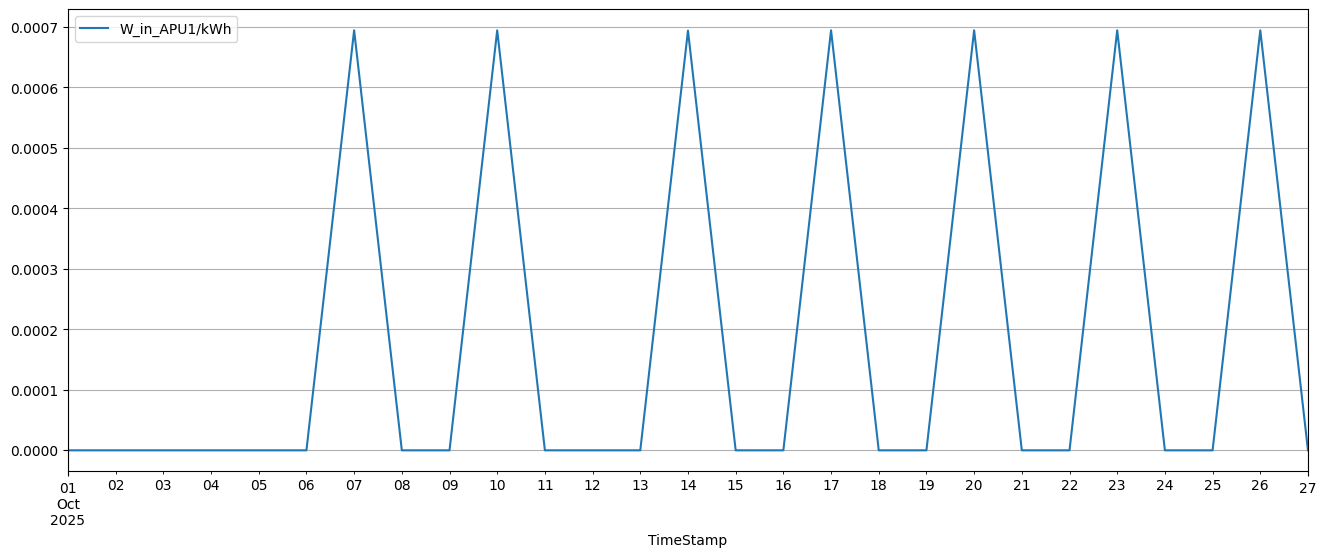

In [17]:
aps1 = aps_new_perminute.copy()
# 1. Đảm bảo cột Time Stamp là kiểu datetime và đặt làm Index
aps1['TimeStamp'] = pd.to_datetime(aps1['TimeStamp'])
aps1.set_index('TimeStamp', inplace=True)

# 2. Sau đó mới chạy lại lệnh vẽ biểu đồ
cols_to_plot = ['W_in_APU1/kWh']
aps1[cols_to_plot].resample('D').mean().plot(subplots=True, figsize=(16, 6), grid=True)
#plt.ylim(350,400)
plt.show()
